In [3]:
import networkx as nx
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

/home/pjgouze/anaconda3/envs/mini_kg_rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def build_kg():
    G = nx.DiGraph()

    # Exemple biomédical simplifié
    edges = [
        ("Tremor", "Parkinson", "symptom_of"),
        ("Rigidity", "Parkinson", "symptom_of"),
        ("Bradykinesia", "Parkinson", "symptom_of"),
        ("Parkinson", "Dopamine Deficiency", "related_to"),
        ("Dopamine Deficiency", "Basal Ganglia", "affects"),
        ("ALS", "Muscle Weakness", "symptom_of"),
        ("Stroke", "Paralysis", "symptom_of"),
    ]

    for u, v, rel in edges:
        G.add_edge(u, v, relation=rel)

    return G

In [5]:
def build_embeddings(G, model):
    node_list = list(G.nodes)
    embeddings = model.encode(node_list)
    embeddings = normalize(embeddings)

    node_to_idx = {node: i for i, node in enumerate(node_list)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}

    return embeddings, node_to_idx, idx_to_node

In [6]:
def build_faiss_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)  # produit scalaire (cosine si normalisé)
    index.add(embeddings.astype('float32'))
    return index

In [7]:
def search_nodes(index, query_embedding, k=5):
    query = query_embedding.reshape(1, -1).astype('float32')
    distances, indices = index.search(query, k)
    return indices[0]

In [8]:
def multi_hop_retrieval(G, query_embedding, index, embeddings, idx_to_node, hops=2, k=5):
    # Step 1: initial retrieval
    start_indices = search_nodes(index, query_embedding, k)
    current_nodes = [idx_to_node[i] for i in start_indices]

    visited = set(current_nodes)

    for _ in range(hops):
        candidates = set()

        # Expand neighbors
        for node in current_nodes:
            neighbors = list(G.neighbors(node))
            candidates.update(neighbors)

        candidates = list(candidates - visited)

        if not candidates:
            break

        # Score candidates
        candidate_embeddings = np.array([
            embeddings[list(idx_to_node.keys())[list(idx_to_node.values()).index(n)]]
            for n in candidates
        ])

        scores = np.dot(candidate_embeddings, query_embedding)

        # Select top-k
        top_k_idx = np.argsort(scores)[-k:]
        current_nodes = [candidates[i] for i in top_k_idx]

        visited.update(current_nodes)

    return list(visited)

In [9]:
def build_subgraph(G, nodes):
    return G.subgraph(nodes)

In [10]:
def linearize_graph(G_sub):
    triples = []
    for u, v, data in G_sub.edges(data=True):
        rel = data.get("relation", "related_to")
        triples.append(f"{u} --{rel}--> {v}")
    return "\n".join(triples)

In [11]:
def generate_answer(context, query):
    return f"""
Question: {query}

Knowledge Graph:
{context}

Answer:
Based on the graph, the most relevant disease is likely Parkinson,
as multiple symptoms connect to it.
"""

In [12]:
def run_pipeline(query):
    print("Building KG...")
    G = build_kg()

    print("Loading model...")
    model = SentenceTransformer("all-MiniLM-L6-v2")

    print("Building embeddings...")
    embeddings, node_to_idx, idx_to_node = build_embeddings(G, model)

    print("Building FAISS index...")
    index = build_faiss_index(embeddings)

    print("Encoding query...")
    query_embedding = model.encode([query])
    query_embedding = normalize(query_embedding)[0]

    print("Running multi-hop retrieval...")
    nodes = multi_hop_retrieval(
        G, query_embedding, index, embeddings, idx_to_node, hops=2, k=3
    )

    print("Retrieved nodes:", nodes)

    print("Building subgraph...")
    subgraph = build_subgraph(G, nodes)

    context = linearize_graph(subgraph)

    print("\nSubgraph:")
    print(context)

    answer = generate_answer(context, query)

    print("\nFinal Answer:")
    print(answer)

## Test des rapport médicaux PARTAGES

In [3]:
import pandas as pd

splits = {'train': 'data/document_metadata/document_metadata_train.parquet', 'dev': 'data/document_metadata/document_metadata_dev.parquet'}
df = pd.read_parquet("hf://datasets/HealthDataHub/PARHAF-infectiology-annotated/" + splits["train"])

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [4]:
from datasets import load_dataset

ds = load_dataset("HealthDataHub/PARHAF-infectiology-annotated", "document_metadata")

/home/pjgouze/anaconda3/envs/mini_kg_rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating dev split: 100%|██████████| 27/27 [00:00<00:00, 7105.87 examples/s]


In [15]:
text = ds['train'][0]["full_text"]
sections = text.split("\n\n")

for i, section in enumerate(sections):
    print(f"\n--- Section {i} ---\n")
    print(section)


--- Section 0 ---

Compte rendu d'hospitalisation

--- Section 1 ---

Service de Maladies infectieuses

--- Section 2 ---

Madame Jolselyne Gallois, âgée de 35 ans, est hospitalisée dans le service de Maladies infectieuses du 10/02/2025 au 13/02/2025.

--- Section 3 ---

Motif d'hospitalisation

--- Section 4 ---

Toux sèche, dyspnée d'effort modérée. Céphalées, asthénie marquée.

--- Section 5 ---

Antécédents médicaux, chirurgicaux, familiaux, allergies

--- Section 6 ---

Antécédents médicaux
- Asthme à prédominance allergique suivi en pneumologie.
- Déficit immunitaire constitutionnel modéré, suivi en consultation d'immunologie.

--- Section 7 ---

Antécédents chirurgicaux
- Aucune chirurgie antérieure.

--- Section 8 ---

Aucune allergie médicamenteuse connue.

--- Section 9 ---

Mode de vie

--- Section 10 ---

Vit à domicile avec son conjoint.

--- Section 11 ---

Travaille en open space de bureau, pas d'exposition professionnelle spécifique.

--- Section 12 ---

Non fumeuse. C

In [16]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['report', 'full_text'],
        num_rows: 107
    })
    dev: Dataset({
        features: ['report', 'full_text'],
        num_rows: 27
    })
})


In [17]:
import json

print(json.dumps(ds["train"][0], indent=2, ensure_ascii=False))

{
  "report": "MALADIES-INFECTIEUSES-00562_CRH",
  "full_text": "Compte rendu d'hospitalisation\n\nService de Maladies infectieuses\n\nMadame Jolselyne Gallois, âgée de 35 ans, est hospitalisée dans le service de Maladies infectieuses du 10/02/2025 au 13/02/2025.\n\nMotif d'hospitalisation\n\nToux sèche, dyspnée d'effort modérée. Céphalées, asthénie marquée.\n\nAntécédents médicaux, chirurgicaux, familiaux, allergies\n\nAntécédents médicaux\n- Asthme à prédominance allergique suivi en pneumologie.\n- Déficit immunitaire constitutionnel modéré, suivi en consultation d'immunologie.\n\nAntécédents chirurgicaux\n- Aucune chirurgie antérieure.\n\nAucune allergie médicamenteuse connue.\n\nMode de vie\n\nVit à domicile avec son conjoint.\n\nTravaille en open space de bureau, pas d'exposition professionnelle spécifique.\n\nNon fumeuse. Consommation d'alcool exceptionnelle.\n\nPas de voyage récent. Pas d'animaux domestiques.\n\nTraitement à l'entrée\n\n-   Budésonide/formotérol 1 bouffée matin 

In [1]:
import pandas as pd
from datasets import load_dataset

dfs = {cfg: load_dataset("HealthDataHub/PARHAF-infectiology-annotated", cfg, split="train").to_pandas()
       for cfg in ["document_metadata", "spans", "relations"]}

for patient_raw in dfs["document_metadata"].itertuples():
    report_id = patient_raw.report
    text = patient_raw.full_text
    report_spans = dfs["spans"][dfs["spans"]["report"] == report_id]
    report_relations = dfs["relations"][dfs["relations"]["report"] == report_id]




/home/pjgouze/anaconda3/envs/mini_kg_rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
patient_raw = next(dfs["document_metadata"].itertuples())

report_id = patient_raw.report
text = patient_raw.full_text

report_spans = dfs["spans"][dfs["spans"]["report"] == report_id]
report_relations = dfs["relations"][dfs["relations"]["report"] == report_id]

print("===== REPORT ID =====")
print(report_id)

print("\n===== TEXT =====\n")
print(text[:1000])  # tronqué pour lisibilité

print("\n===== SPANS =====")
print(report_spans.head(10))

print("\n===== RELATIONS =====")
print(report_relations.head(10))

===== REPORT ID =====
MALADIES-INFECTIEUSES-00562_CRH

===== TEXT =====

Compte rendu d'hospitalisation

Service de Maladies infectieuses

Madame Jolselyne Gallois, âgée de 35 ans, est hospitalisée dans le service de Maladies infectieuses du 10/02/2025 au 13/02/2025.

Motif d'hospitalisation

Toux sèche, dyspnée d'effort modérée. Céphalées, asthénie marquée.

Antécédents médicaux, chirurgicaux, familiaux, allergies

Antécédents médicaux
- Asthme à prédominance allergique suivi en pneumologie.
- Déficit immunitaire constitutionnel modéré, suivi en consultation d'immunologie.

Antécédents chirurgicaux
- Aucune chirurgie antérieure.

Aucune allergie médicamenteuse connue.

Mode de vie

Vit à domicile avec son conjoint.

Travaille en open space de bureau, pas d'exposition professionnelle spécifique.

Non fumeuse. Consommation d'alcool exceptionnelle.

Pas de voyage récent. Pas d'animaux domestiques.

Traitement à l'entrée

-   Budésonide/formotérol 1 bouffée matin et soir en inhalation.

-

In [ ]:
for rel in report_relations.itertuples():
    print(rel)
    print(' ...')

Pandas(Index=0, report='MALADIES-INFECTIEUSES-00562_CRH', relation_id=1104, begin=2674, end=2698, source_term_id=1084, source_text='Streptococcus pneumoniae', target_term_id=1100, target_text='Hémocultures prélevées aux urgences: 3 flacons sur 4 positifs', attribute_RelationAgentPathogene='AgentPathogene', attribute_RelationSitePrimaire=nan, attribute_RelationOrigine=nan)
 ...
Pandas(Index=1, report='MALADIES-INFECTIEUSES-00562_CRH', relation_id=1105, begin=3303, end=3344, source_term_id=1086, source_text='pneumopathie franche lobaire aiguë droite', target_term_id=1087, target_text='bactériémie', attribute_RelationAgentPathogene=nan, attribute_RelationSitePrimaire='SitePrimaire', attribute_RelationOrigine=nan)
 ...
Pandas(Index=2, report='MALADIES-INFECTIEUSES-00562_CRH', relation_id=1106, begin=3379, end=3403, source_term_id=1088, source_text='Streptococcus pneumoniae', target_term_id=1087, target_text='bactériémie', attribute_RelationAgentPathogene='AgentPathogene', attribute_Relatio

In [5]:
import pandas as pd

relations = dfs["relations"].copy()

# transformer les colonnes d'attributs en une seule colonne
relation_cols = [
    "attribute_RelationAgentPathogene",
    "attribute_RelationSitePrimaire",
    "attribute_RelationOrigine"
]

def extract_relation_type(row):
    for col in relation_cols:
        if pd.notna(row[col]):
            return row[col]
    return None

relations["relation_type"] = relations.apply(extract_relation_type, axis=1)

relation_counts = relations["relation_type"].value_counts()
print(relation_counts)



relation_type
Origine           569
SitePrimaire      395
AgentPathogene    394
Name: count, dtype: int64


In [6]:
relations_per_doc = relations.groupby("report").size()

print(relations_per_doc.describe())



count    107.000000
mean      12.934579
std        7.334682
min        1.000000
25%        8.000000
50%       12.000000
75%       16.000000
max       44.000000
dtype: float64


In [7]:
top_sources = relations["source_text"].value_counts().head(10)
print(top_sources)



source_text
Streptococcus pneumoniae      77
Escherichia coli              56
ECBU                          56
E. coli                       35
point de départ pulmonaire    29
Staphylococcus aureus         29
pneumopathie                  27
Pneumopathie d'inhalation     23
SAMS                          22
périphériques                 21
Name: count, dtype: int64


In [8]:
top_targets = relations["target_text"].value_counts().head(10)
print(top_targets)



target_text
bactériémie                 331
Hémocultures                127
hémocultures                 84
Streptococcus pneumoniae     71
Escherichia coli             57
E. coli                      53
Bactériémie                  44
SAMS                         41
bactériémiante               36
Staphylococcus aureus        32
Name: count, dtype: int64


In [9]:
pair_counts = (
    relations
    .groupby(["source_text", "target_text", "relation_type"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print(pair_counts.head(10))



                    source_text       target_text   relation_type  count
363    Streptococcus pneumoniae       bactériémie  AgentPathogene     39
125            Escherichia coli       bactériémie  AgentPathogene     25
359    Streptococcus pneumoniae      Hémocultures  AgentPathogene     23
122            Escherichia coli      Hémocultures  AgentPathogene     17
92                         ECBU  Escherichia coli         Origine     15
228   Pneumopathie d'inhalation       bactériémie    SitePrimaire     13
636  point de départ pulmonaire       bactériémie    SitePrimaire     13
65                      E. coli       bactériémie  AgentPathogene     11
604                pneumopathie       bactériémie    SitePrimaire     11
102                        ECBU      hémocultures    SitePrimaire     11


In [12]:
pivot = pd.pivot_table(
    relations,
    index="source_text",
    columns="relation_type",
    aggfunc="size",
    fill_value=0
)

pivot

relation_type,AgentPathogene,Origine,SitePrimaire
source_text,,,
1er jet urinaire,0,6,0
"38,2 °C.",0,0,1
A.xylosoxidans,1,0,0
Abcès hépatique,0,4,2
Achromobacter xylosoxidans,1,0,0
...,...,...,...
à porte d'entrée cutanée,0,0,1
écouvillon anal,0,2,0
écouvillon oropharyngé,0,2,0


In [13]:
import networkx as nx

G = nx.DiGraph()

for row in relations.itertuples():
    G.add_edge(
        row.source_text,
        row.target_text,
        relation=row.relation_type
    )

print(nx.number_of_nodes(G), nx.number_of_edges(G))

386 826


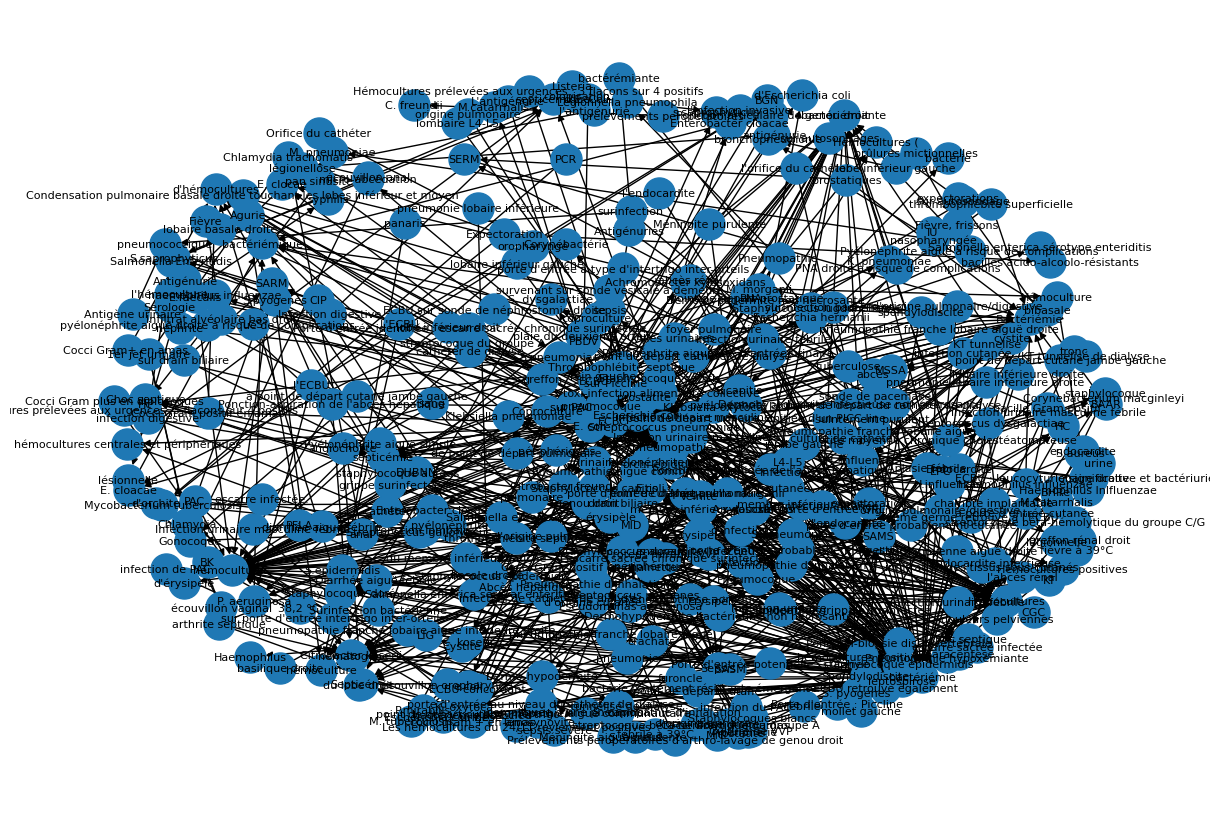

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

for row in relations.itertuples():
    G.add_edge(
        row.source_text,
        row.target_text,
        relation=row.relation_type
    )

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, k=0.5)  # layout force-directed

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.show()

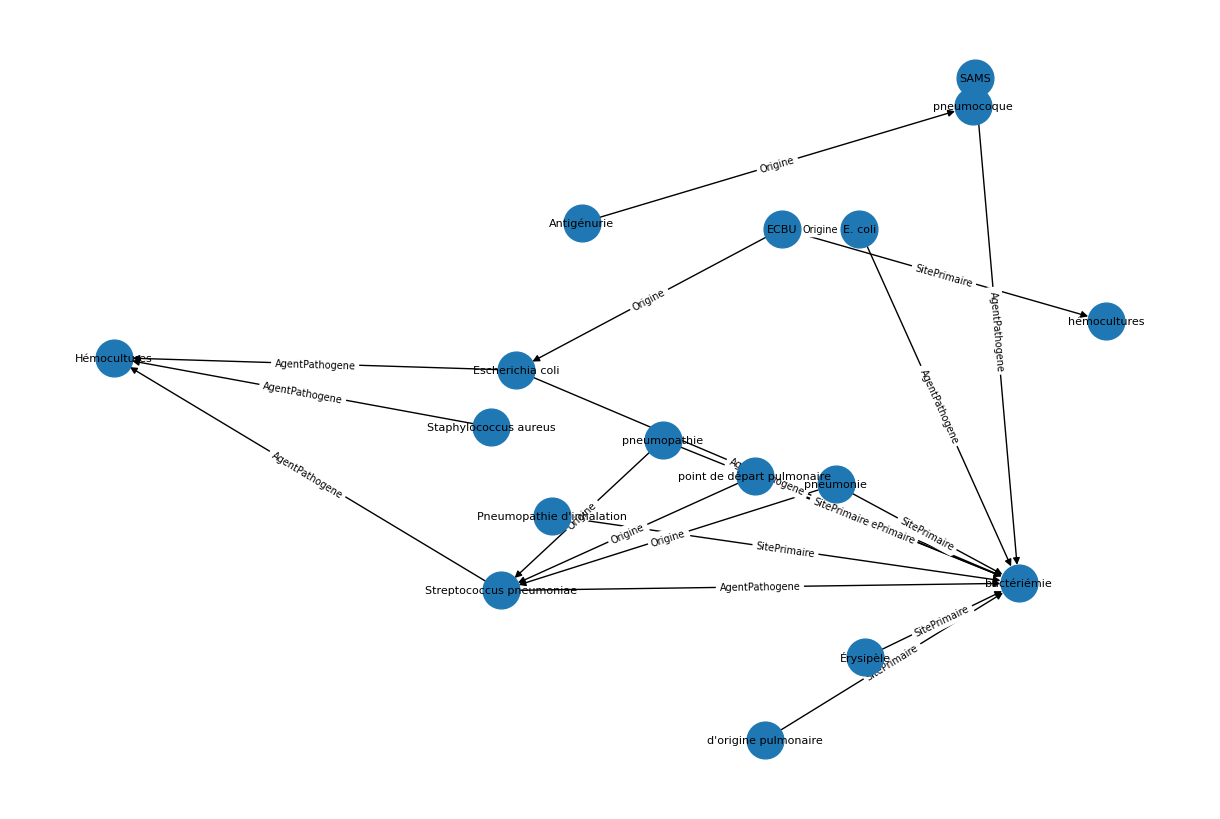

In [16]:
# garder uniquement les relations fréquentes
top_pairs = pair_counts.head(20)

G_small = nx.DiGraph()

for _, row in top_pairs.iterrows():
    G_small.add_edge(
        row["source_text"],
        row["target_text"],
        relation=row["relation_type"]
    )

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_small, k=0.8)

nx.draw(G_small, pos, with_labels=True, node_size=700, font_size=8)

# ajouter labels des relations
edge_labels = {
    (u, v): d["relation"]
    for u, v, d in G_small.edges(data=True)
}

nx.draw_networkx_edge_labels(G_small, pos, edge_labels=edge_labels, font_size=7)

plt.show()